# Testing state abstraction on Ott's data

Now that we have established that the bayesian hierarchical models we have devised are able to 

While we aim to collect a whole new data set for this project, we can nontheless test whether our state abstraction model of existing data. The design we aim to use is adapted Ott et al.'s design. For our purpose, we will increase the number of states compared to the original, to make it more difficult for participants to solve the MDP to push them to resort to abstraction. Therefore, the original design is not necessarily geared toward state abstraction. Nonetheless, participants were observed to behave suboptimally in the original design, which might indicate that already the state space size of the original study might be too large for participants to deal with. We can therefore test our state abstraction model on these data. First, we will compute the pairwise distances of each states in the original state space, generate abstracted MDP at various $\epsilon$ levels ($\epsilon=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]$) and compare the results of that model to the model from Ott et al.

## Compute pairwise distances:

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.stats import zscore
from stabst.utils import plot_state_matrix, beh_barplot, abstract2ground_value
from scipy.special import expit
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import arviz as az
import pymc as pm


# ===================================================================================
# Prepare the data:
# Download data from Florian's repo:
data = pd.read_csv("../data/raw_data/all_participants_data.csv", on_bad_lines='skip')
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Remove the 
# Get subject IDs:
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
coords = {
    "observation": np.arange(len(data)),
    "subject": subj_labels,
}
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

In [ ]:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()
# Compute pairwise distances:
if not os.path.isfile(f'../data/bids/limited_energy/derivatives/state_abstraction/bisimulation_distance_matrix_gamma_{gamma}.npy'):
    distances_matrix = task_mdp.bisim_metric(gamma=0.99, tol=1e-3, njobs=-1, max_iters=1000)
    distances_matrix = distances_matrix / np.max(distances_matrix)
    if not os.path.isdir("../data/bids/limited_energy/derivatives/state_abstraction"):
        os.makedirs("../data/bids/limited_energy/derivatives/state_abstraction")
    np.save(f'../data/bids/limited_energy/derivatives/state_abstraction/bisimulation_distance_matrix_gamma_{gamma}.npy', distances_matrix)
else:
    distances_matrix = np.load(f'../data/bids/limited_energy/derivatives/state_abstraction/bisimulation_distance_matrix_gamma_{gamma}.npy')

# Compute decision values for each abstraction level:

In [ ]:
unique_dist = np.unique(np.round(distances_matrix, decimals=3))
n_states = len(task_mdp.states)
abstraction_distances = []
DVs = []

for eps in unique_dist: #unique_dist:
    # Generate abstracted MDP at that level of abstraction:
    abstract_mdp, state_classes, class_of_state = task_mdp.distance_reduce_mdp(eps + 0.0001, distance_matrix=distances_matrix)
    if n_states - len(abstract_mdp.states) < 10:
        continue
    else:
        n_states = len(abstract_mdp.states)
        abstraction_distances.append(eps)
    # Solve the MDP:
    V_R, Q_R = abstract_mdp.backward_induction()
    # Project back to Ground space:
    V_from_abstract, Q_from_abstract = abstract2ground_value(class_of_state, V_R, Q_R)
    # Put back the original Q values for non intermediate offers:
    for state in task.states:
        if state[1] == 1 or state[1] == 4:
            Q_from_abstract[task.s2i[state], :] = Q_full[task.s2i[state], :]
    # Add to decision 
    dv = Q_from_abstract[:, 1] - Q_from_abstract[:, 0]
    # Loop through each trial to set DV:
    dv_trials = []
    mdl_sim_resps = []
    decision_match = []
    for trial_i, trial in data.iterrows():
        e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
        fc = transitions_costs[trial.transition][1]
        dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
        # Simulate data according to that plan:
        mdl_sim_resps.append(np.random.binomial(1, expit(dv[task.s2i[(e, o, cc, fc, t)]])))
        decision_match.append(1 - np.abs(trial.response - mdl_sim_resps[-1]))
    data[f'DV-eps: {eps}'] = dv_trials


# Fit Florian's hybrid model for reference

In [ ]:
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
traces = {}
coords = {
    "subject": subj_labels,
    "coef": ["beta_14", "beta_23", "beta_1", "beta_2", "beta_3", "beta_4", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data[f"DV-eps: {0.0}"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_2 = pm.Data("is_2", data["is_2"])
    is_3 = pm.Data("is_3", data["is_3"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_14 = pm.Data("is_14", data["is_14"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv * is_14 +
                             beta_sub[subj_idx, 1] * dv * is_23 +
                             beta_sub[subj_idx, 2] * is_1 +
                             beta_sub[subj_idx, 3] * is_2 +
                             beta_sub[subj_idx, 4] * is_3 +
                             beta_sub[subj_idx, 5] * is_4 +
                             beta_sub[subj_idx, 6] * is_maxE +
                             beta_sub[subj_idx, 7] * is_minE_LC +
                             beta_sub[subj_idx, 8] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)
    traces['HM'] =  pm.sample(1000, tune=1000, target_acceptance=0.95, idata_kwargs={"log_likelihood": True})
    
for eps_i, eps in enumerate(abstraction_distances[1:7]):
    # Model the data:
    with hierarchical_binomial_regression:
        pm.set_data({"Decision values": data[f'DV-eps: {eps}']})
        traces[f'HM, DV={eps}'] = pm.sample(1000, tune=1000, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 187 seconds.


## Prepare data for model fitting:

In [ ]:
# Extract the data of one subject:
coords = {
    "subject": subj_labels,
    "coef": ["beta_dv", "beta_01", "beta_02", "beta_03", "beta_d04", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data[f"DV-eps: {0.0}"])
    is_1 = pm.Data("is_1", data["is_1"])
    is_2 = pm.Data("is_2", data["is_2"])
    is_3 = pm.Data("is_3", data["is_3"])
    is_4 = pm.Data("is_4", data["is_4"])
    is_14 = pm.Data("is_14", data["is_14"])
    is_23 = pm.Data("is_23", data["is_23"])
    is_basic = pm.Data("is_basic", data["is_basic"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv +
                             beta_sub[subj_idx, 1] * is_1 +
                             beta_sub[subj_idx, 2] * is_2 +
                             beta_sub[subj_idx, 3] * is_3 +
                             beta_sub[subj_idx, 4] * is_4 +
                             beta_sub[subj_idx, 5] * is_maxE +
                             beta_sub[subj_idx, 6] * is_minE_LC +
                             beta_sub[subj_idx, 7] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)

for eps_i, eps in enumerate(abstraction_distances[1:7]):
    # Model the data:
    with hierarchical_binomial_regression:
        pm.set_data({"Decision values": data[f'DV-eps: {eps}']})
        traces[f'y ~ DV_{eps} + is_1-4 + MaxE + MinELC + MinEHC'] = pm.sample(1000, tune=1000, idata_kwargs={"log_likelihood": True})
        data[f'p(y=1|y_obs)@eps={eps}'] = traces[f'y ~ DV_{eps} + is_1-4 + MaxE + MinELC + MinEHC'].posterior.p.mean(dim=["chain", "draw"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 167 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 167 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 162 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 162 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 161 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [ ]:
# Extract the data of one subject:
coords = {
    "subject": subj_labels,
    "coef": ["beta_dv", "beta_maxE", "beta_mineE_LC", "beta_mineE_HC"],
}

with pm.Model(coords=coords) as hierarchical_binomial_regression:
    y_obs = pm.Data("y_obs", data["response"])
    dv = pm.Data("Decision values", data[f"DV-eps: {0.0}"])
    is_maxE = pm.Data("is_maxE", data["is_full_energy"])
    is_minE_LC = pm.Data("is_minE_LC", data["is_low_energy_LC"])
    is_minE_HC = pm.Data("is_minE_HC", data["is_low_energy_HC"])
    subj_idx = pm.Data("subj_idx", subj_idx_raw)

    # Population level priors:
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=2, dims="coef")
    sigma_pop = pm.HalfNormal('sigma_pop', sigma=2, dims="coef")
    # Non centered parametrization of within subject coefficients
    z = pm.Normal("z", 0, 1, dims=("subject", "coef"))
    beta_sub = pm.Deterministic("beta_sub", beta_pop + z * sigma_pop, dims=("subject","coef"))

    # Likelihood
    p = pm.Deterministic("p", 
                         pm.math.sigmoid(
                             beta_sub[subj_idx, 0] * dv +
                             beta_sub[subj_idx, 1] * is_maxE +
                             beta_sub[subj_idx, 2] * is_minE_LC +
                             beta_sub[subj_idx, 3] * is_minE_HC
                             ))
    pm.Bernoulli("y", p=p, observed=y_obs)

for eps_i, eps in enumerate(abstraction_distances[1:7]):
    # Model the data:
    with hierarchical_binomial_regression:
        pm.set_data({"Decision values": data[f'DV-eps: {eps}']})
        traces[f'y ~ DV_{eps} + MaxE + MinELC + MinEHC'] = pm.sample(1000, tune=1000, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 89 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 86 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 83 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 86 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvr

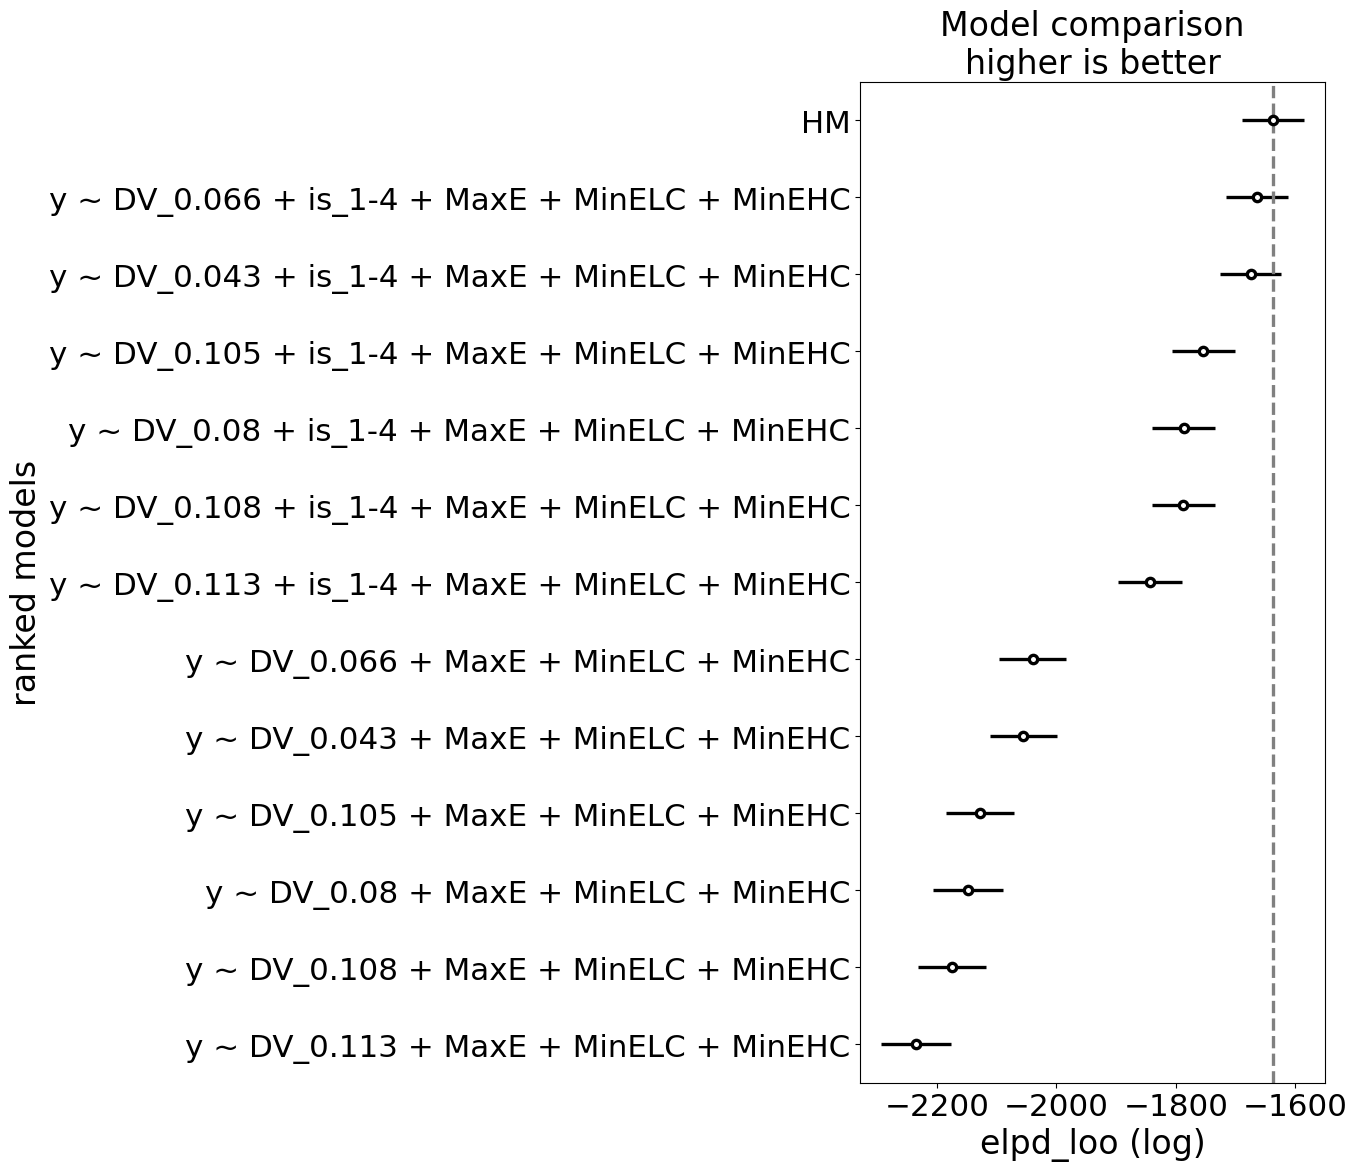

In [ ]:
# Compare models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);

# Plotting the results:
To evalute the fit of the data, we will plot the data alongside the posterior, to evaluate how well each abstraction level is doing:

KeyError: "Columns not found: 'p(y=1|y_obs)@eps=0.0'"

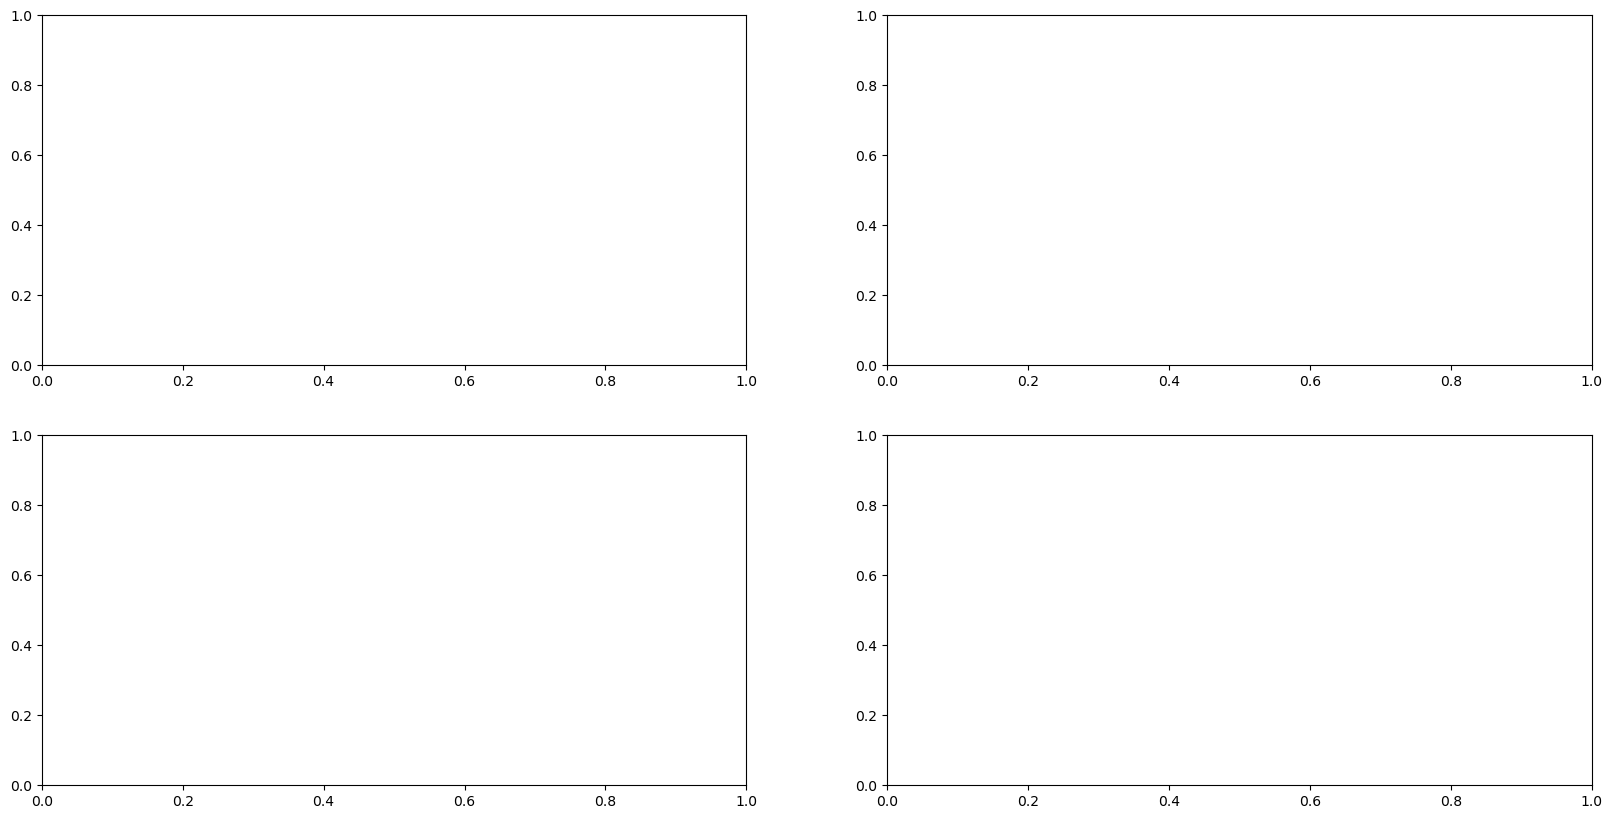

In [ ]:
beh_barplot(data, abstraction_distances[0:7], transitions_costs, "p(y=1|y_obs)@eps=")

The plotting of the results go in the direction of the model comparison: the model without abstraction performs overall closest to the actual participants behaviours. But to be sure, let's have a look in more details in each condition:

(<Figure size 1200x800 with 17 Axes>,
 array([[<Axes: title={'center': 'Offer = 1'}, ylabel='cc=1, fc=1 \n Energy'>,
         <Axes: title={'center': 'Offer = 2'}>,
         <Axes: title={'center': 'Offer = 3'}>,
         <Axes: title={'center': 'Offer = 4'}>],
        [<Axes: ylabel='cc=1, fc=2 \n Energy'>, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='cc=2, fc=1 \n Energy'>, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='Trials', ylabel='cc=2, fc=2 \n Energy'>,
         <Axes: xlabel='Trials'>, <Axes: xlabel='Trials'>,
         <Axes: xlabel='Trials'>]], dtype=object))

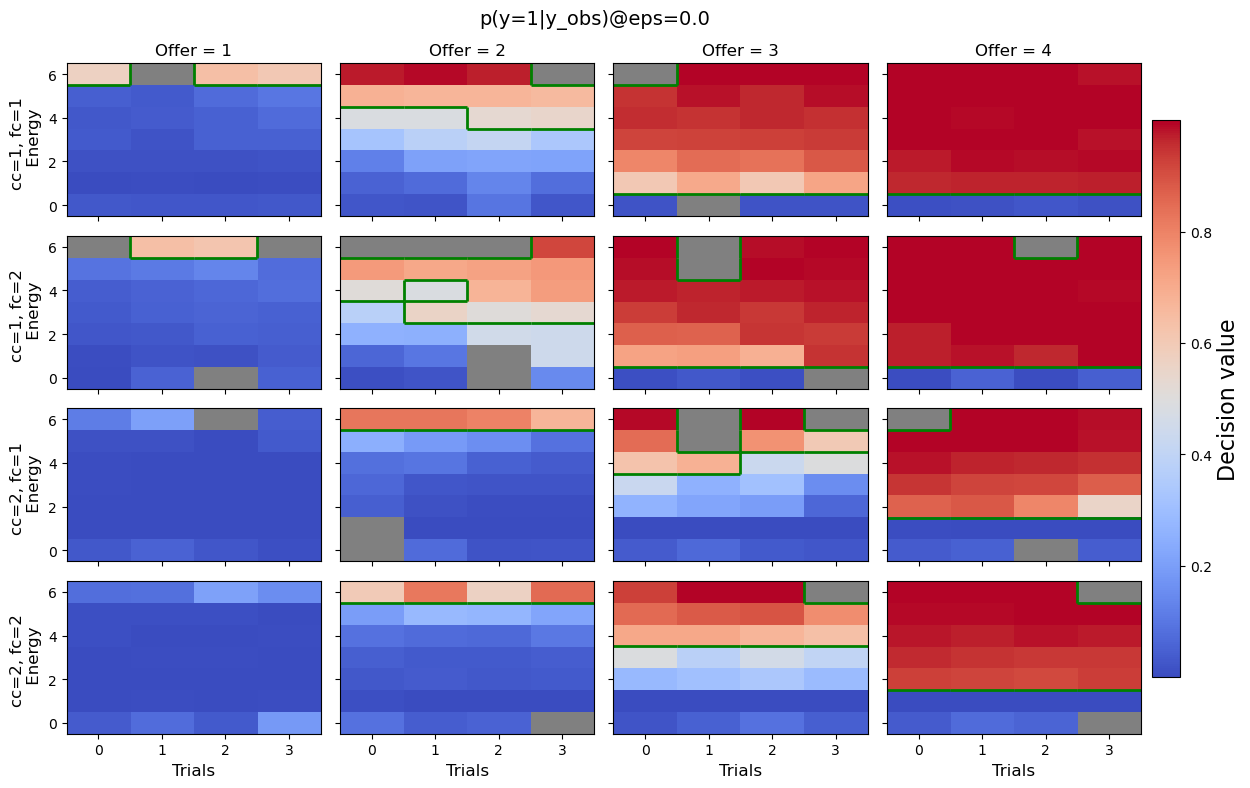

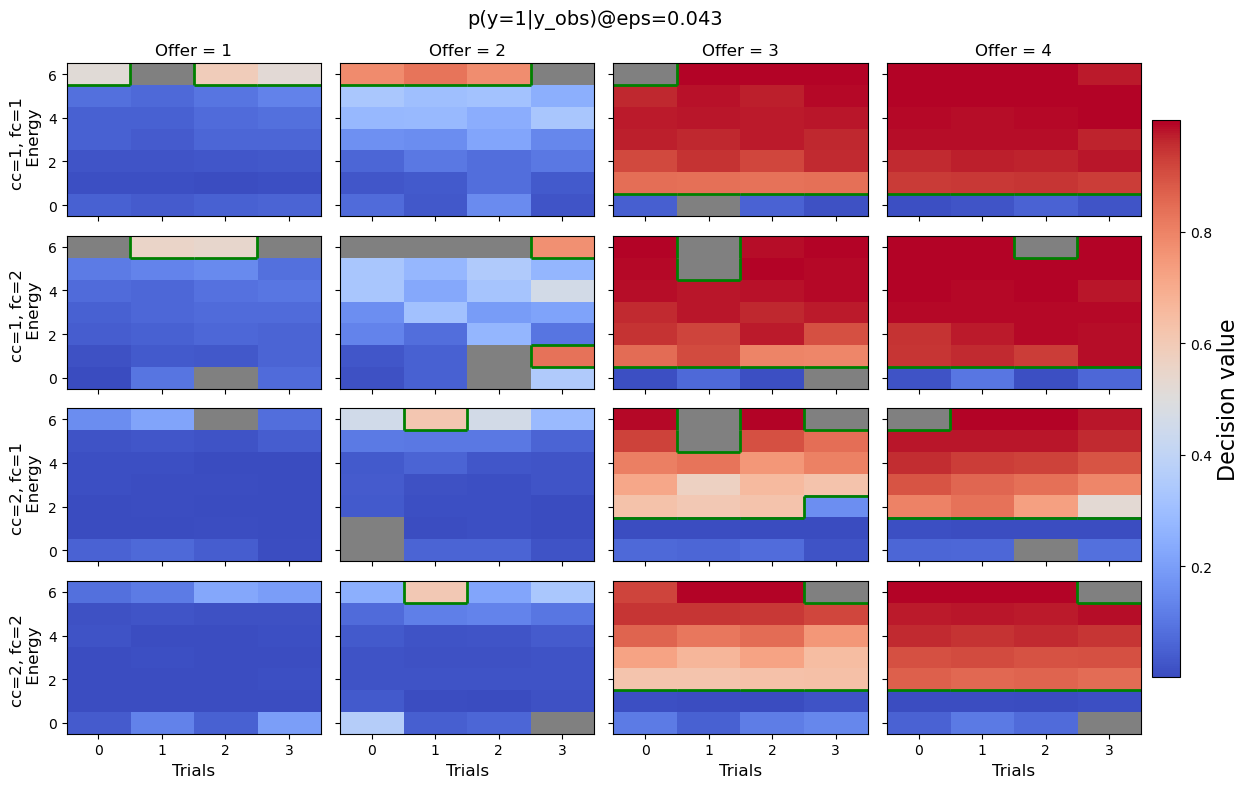

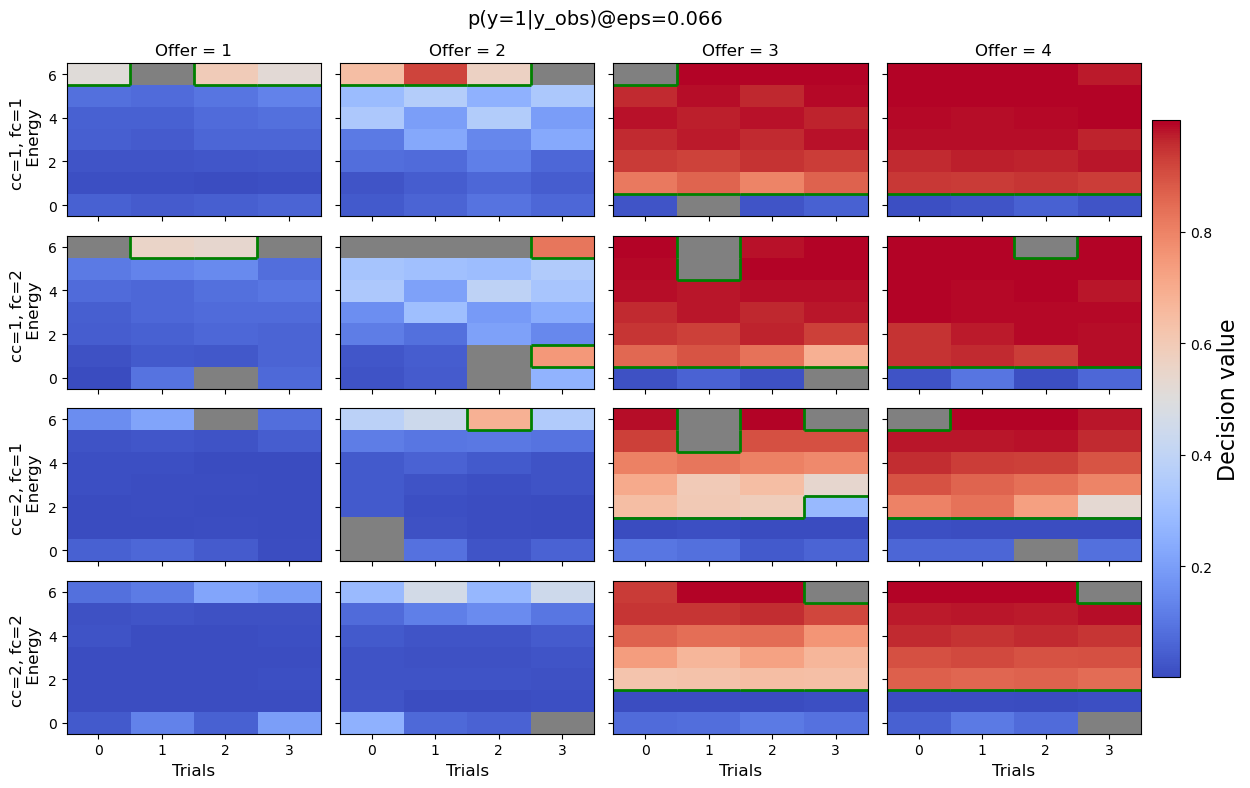

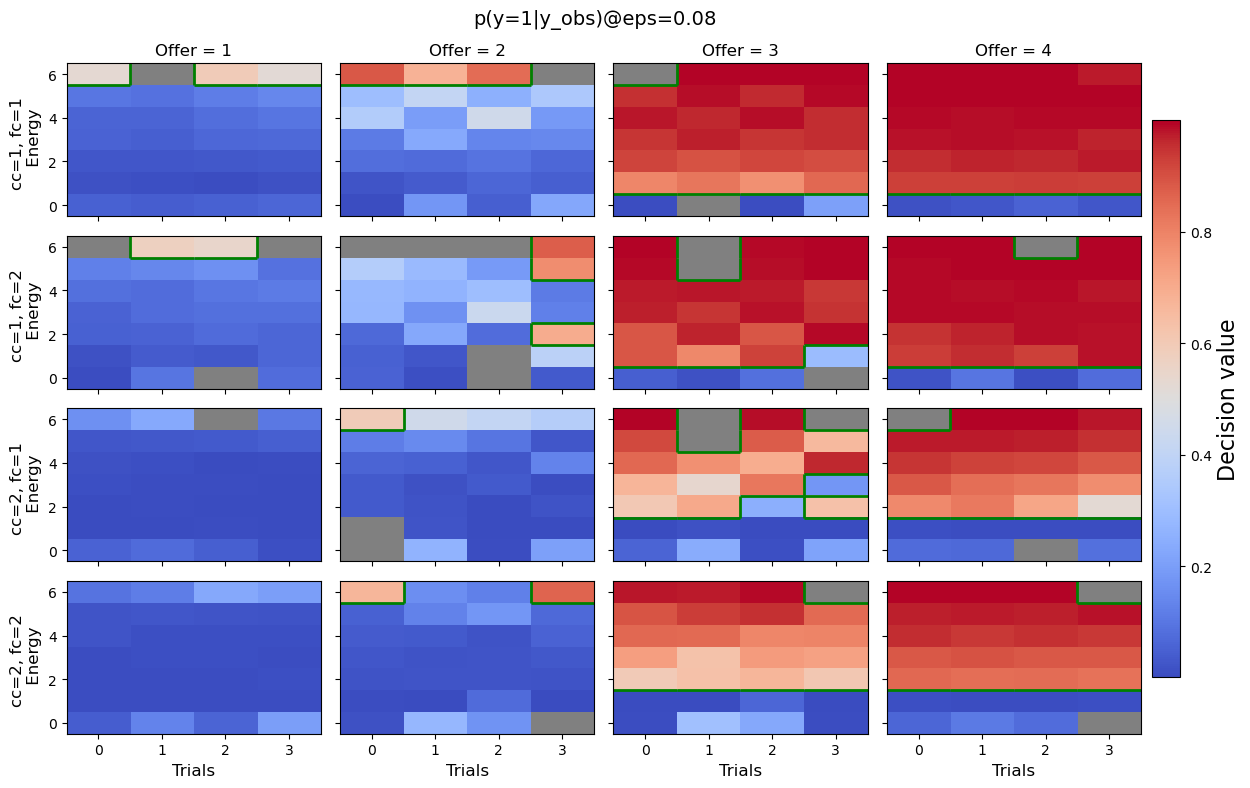

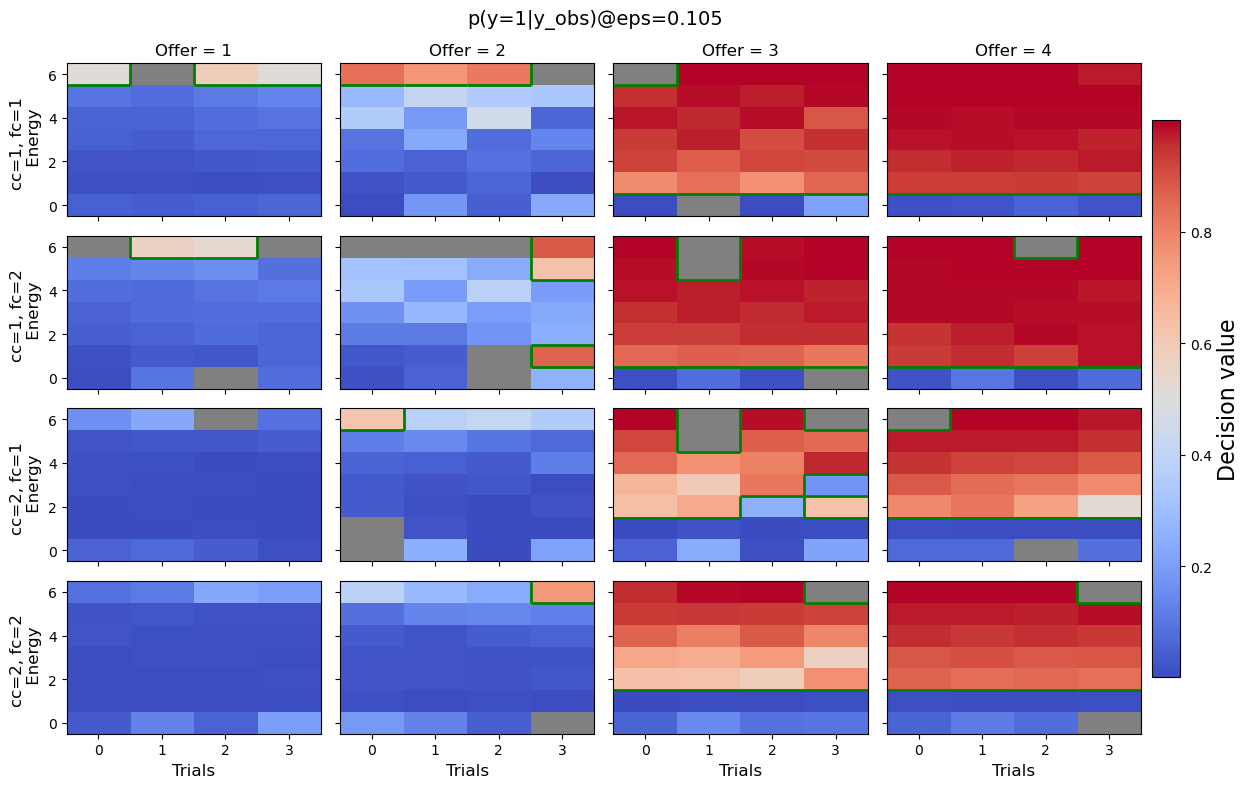

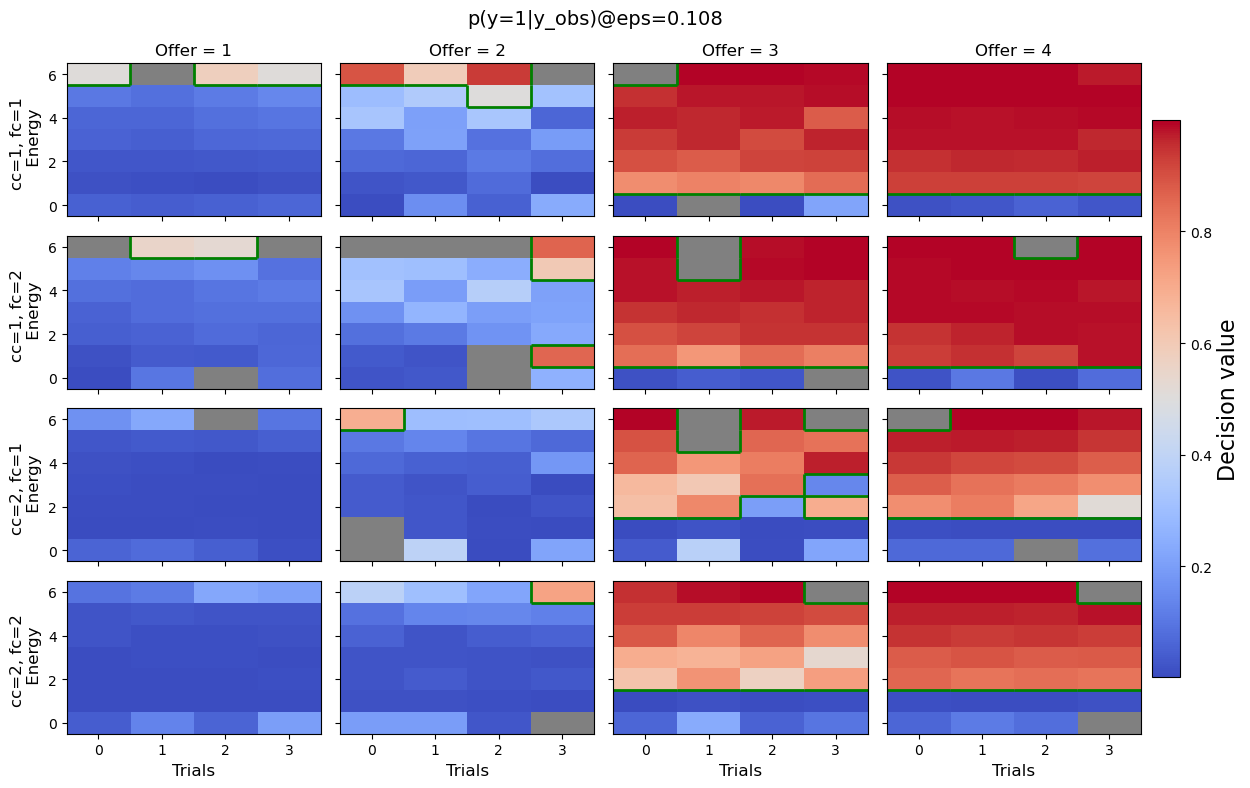

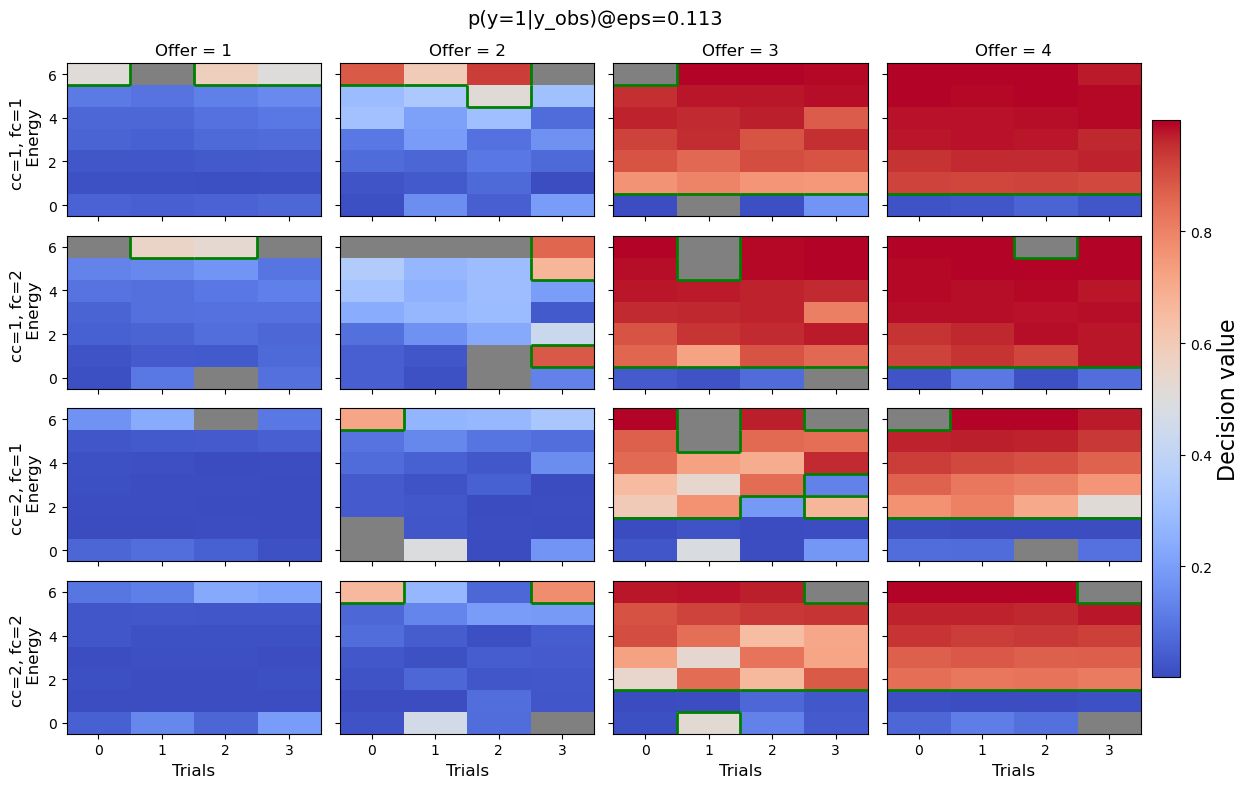

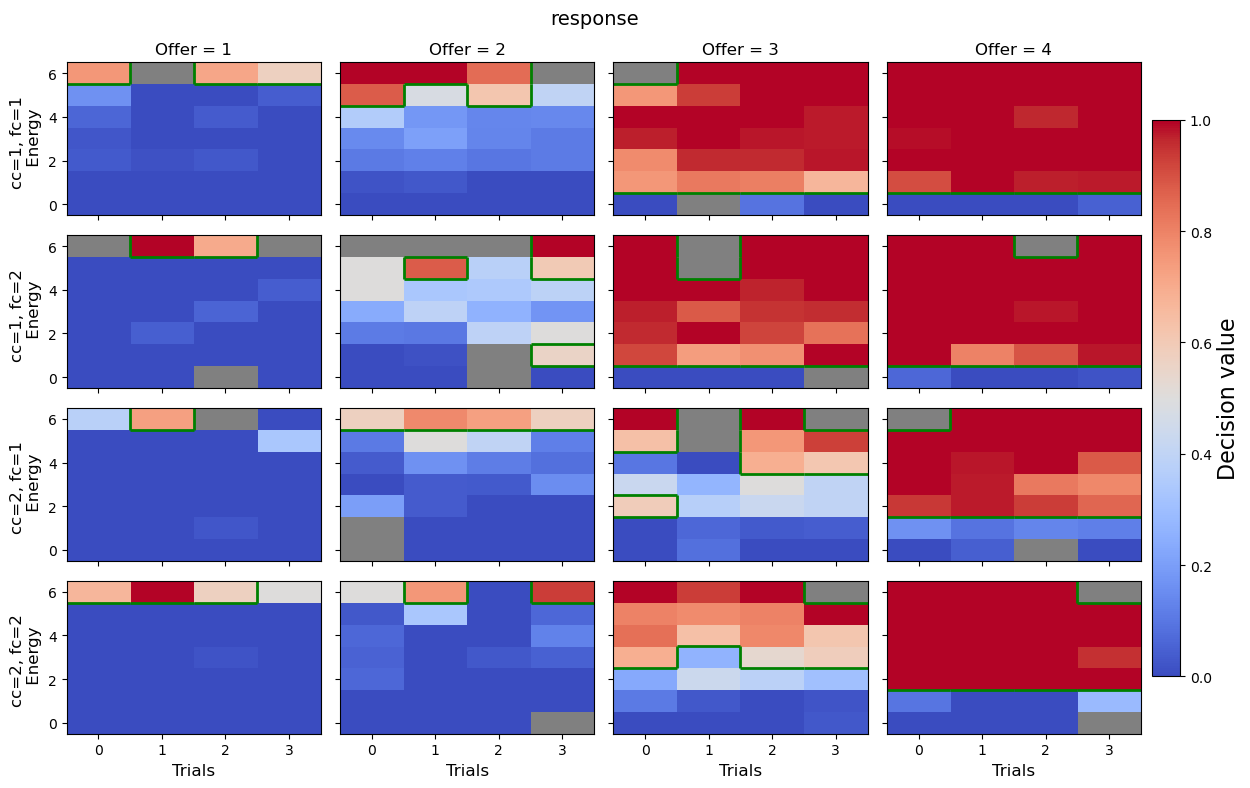

In [ ]:
# Loop through each abstraction distances:
state_cols = ["energy", "reward", "energy_cost", "fc", "trial"]
cmap = plt.get_cmap('coolwarm')
cmap.set_bad("grey")
for eps in abstraction_distances[0:7]:
    mean_resp = np.empty(len(task_mdp.states))
    for state in task_mdp.states:
        mean_resp[task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), f'p(y=1|y_obs)@eps={eps}'].mean()
    # Plot:
    task_mdp.plot_dv(mean_resp, title=f'p(y=1|y_obs)@eps={eps}', tmax=4, cmap=cmap, cmap_midpoint=0.5, boundary_threshold=0.5)

mean_resp = np.empty(len(task_mdp.states))
for state in task_mdp.states:
    mean_resp[task_mdp.s2i[*state]] = data.loc[(data[state_cols].to_numpy() == state).all(axis=1), 'response'].mean()
# Plot:
task_mdp.plot_dv(mean_resp, title='response', tmax=4, cmap=cmap, cmap_midpoint=0.5, boundary_threshold=0.5)